# Influence of conditioning
One matrix with smallest singular value `smin`: the number of iterations to reach `eps` for each D, against the predicted $K_D$. Each iterate is frozen once its error reaches `eps`. Change `smin` (or `dtype`) and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import orbit_tools, plots
from experiments.conditioning import ConditioningConfig, run_conditioning
%matplotlib inline

In [4]:
cfg = ConditioningConfig(
    m=128, n=128, rank=32, smin=1e-3, degrees=[1, 2, 3, 4],
    k_max=40,     # steps run at most
    eps=1e-10,    # accuracy for the step counts and the freeze (also sets the predicted K_D)
    dtype=torch.float64, device="cpu", seed=0,
)

res = run_conditioning(cfg)

D=1: 22 iterations  (predicted K_D = 25)
D=2: 14 iterations  (predicted K_D = 16)
D=3: 11 iterations  (predicted K_D = 13)
D=4: 10 iterations  (predicted K_D = 11)


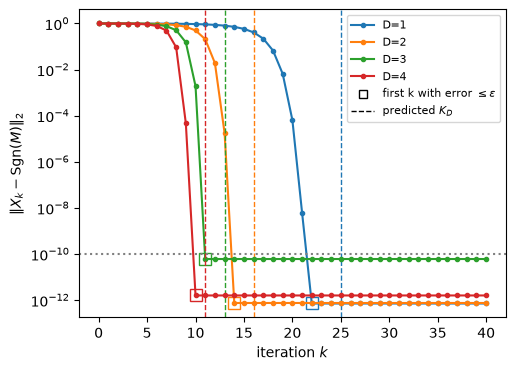

In [5]:
orbit_tools.report_iterations(res["iterations"], res["predicted"])
plots.plot_error_curves(res["error"], eps=cfg.eps, predicted=res["predicted"]);